<a href="https://colab.research.google.com/github/wbandabarragan/Bootcamp2025/blob/main/CursoA_Semana1/Tareas/tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1: Visualización con Python

Esta tarea consiste en añadir ruido a los perfiles de densidad 1D, 2D y 3D, que revisamos en este cuaderno en clase:

https://github.com/Astronomia-Ecuador/Bootcamp2025/blob/main/CursoA_Semana1/Clase_02/Clase_2a.ipynb

Al añadir ruido con cierta amplitud, tendremos perfiles mucho más realistas para las nubes.

Pueden trabajar individualmente o en grupos de 2 personas.

## Instrucciones:

- ¿Cómo generar ruido? Podemos utilizar generadores de números aleatorios con numpy:

https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html

-  Para el caso 1D, debemos graficar:

$$\rho(z) = \rho_0 \, \text{sech}^2 \left( \frac{z}{H} \right) + N(x)$$

donde la función $N(x)$ es un vector (arreglo 1D) de ruido generado con NumPy y H es:

$$H = \frac{c_s}{\sqrt{2 \pi \mathit{G} \rho_0}}$$


In [1]:
#

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const

In [2]:
# Constants

G = const.G * 1e6 * 1e-3    # gravitational const in cgs
cs = 2e4                    # sound speed in cm/s (sound speed in cm/s)
rho0 = 1e-18                # central density in g/cm^3 (for dense molecular cloud)

# print(G, cs, rho0)



In [3]:
def one_dim_dens_profile_noise(graph=4, amp=0.3, defin=500):
    """
    Función generadora de ruido utilizando numpy.random
    Input:  graph -> amplitud del grafico
            amp   -> valor de amplitud (e.g. +-5sigma)
    Output: array with random values

    """
    H = cs / np.sqrt(2 * np.pi * G * rho0) # Scale height
    z = np.linspace(-graph*H, graph*H, defin)
    rho = rho0 * (1 / np.cosh(z / H))**2
    noise_list = rho * (1 + np.random.uniform(-amp, amp, size=defin))


    return rho / rho0, noise_list / rho0, z /H

In [4]:
# print(noise_function())

rho_norm, rho_noise_norm, height_norm = one_dim_dens_profile_noise(graph=7, amp=0.2, defin=500)

# print(c)

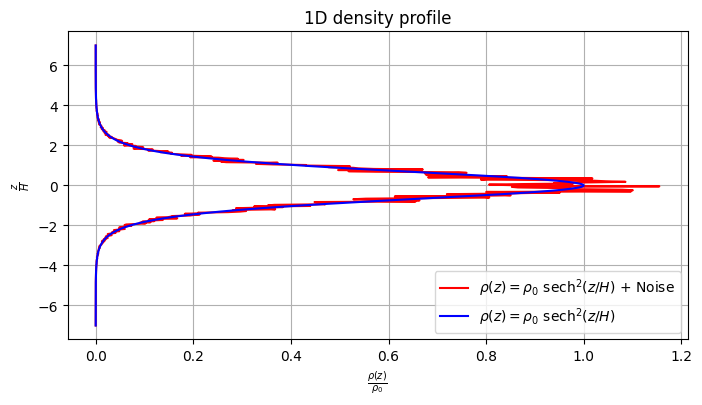

In [5]:
# plotting

plt.figure(figsize=(8,4))

plt.plot(rho_noise_norm, height_norm, color = 'red', label=r'$\rho(z) = \rho_0 \ \mathrm{sech}^2(z/H)$ + Noise')
plt.plot(rho_norm, height_norm, color = 'blue', label = r'$\rho(z) = \rho_0 \ \mathrm{sech}^2(z/H)$' )

plt.xlabel(r'$\frac{\rho(z)}{\rho_0}$')
plt.ylabel(r'$\frac{z}{H}$')

plt.title("1D density profile")
plt.grid(True)

plt.legend(loc=4)

plt.show()


- Para el caso 2D, debemos graficar:

$$\rho(r) = \frac{\rho_0}{\left(1 + \frac{r^2}{8 H^2} \right)^2}+N(r)$$

donde la función $N(r)$ es una matriz (arreglo 2D) de ruido generado con NumPy.
En este caso $H$ está dador por:

$$ H = \frac{c_s}{\sqrt{4 \pi \mathit{G} \rho_0}} $$


In [6]:
def two_dim_dens_prof_noise(amp=0.3, rmax=3, defin=600):
  """
  Función que genera ruido aleatorio para agregar a una nube de densidad, para tener
  una mejor aproximación

  Input: amp -> amplitud del ruido.

  """
  H = cs / np.sqrt(4 * np.pi * G * rho0)

  Rmax = rmax * H

  # Meshgrid creation
  x = np.linspace(-Rmax, Rmax, defin)
  y = np.linspace(-Rmax, Rmax, defin)
  x_2d, y_2d = np.meshgrid(x, y)


  R = np.sqrt(x_2d**2 + y_2d**2)

  rho = rho0 / (1 + R**2 / (8 * H**2))**2

  noise = 1 + np.random.uniform(-amp, amp, (defin, defin))

  rho_noise2d = rho * noise


  return rho / np.max(rho), rho_noise2d / np.max(rho), x_2d / H, y_2d / H

In [7]:
a, b, c, d = two_dim_dens_prof_noise(amp=0.9, defin = 100)

In [8]:
from matplotlib import cm
# Si queremos plotear la superficie primero creamos una proyeccion del

plt.figure(figsize=(6, 5))

#plt.contourf(x_2d/H, y_2d/H, np.log10(rho_norm), levels=50, cmap='inferno')
# ax = plt.axes(projection = "3d")

# ax.contour3D(c, d, np.log10(b),500, cmap=cm.inferno)

# cbar = plt.colorbar(label=r'$\log_{10}(\rho / \rho0)$')

# plt.xlabel(r'$\frac{x}{H}$')
# plt.ylabel(r'$\frac{y}{H}$')


# plt.show()
#plt.savefig("./drive/MyDrive/Bootcamp2025/images/surface.png")

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

- Para el caso 3D, debemos graficar:

$$\rho(r) = \frac{\rho_0}{\left(1 + \frac{r^2}{r_c^2} \right)^{3/2}}+N(r)$$

donde la función $N(r)$ es una matriz (arreglo 3D) de ruido generado con NumPy.


In [9]:
# Importing library
import plotly.graph_objects as go

In [10]:

def three_dim_dens_prof_noise(amp=0.3, rc=1.0, N = 128, L = 6.0):
  # Axes
  x = y = z = np.linspace(-L, L, N)

  # 3D grid
  X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

  print(X.shape)
  print(type(X))
  # Radial coordinate
  R = np.sqrt(X**2 + Y**2 + Z**2)

  # Density field (approximation to Lane-Emden equation)
  rho = rho0 / (1 + (R / rc)**2)**1.5

  noise = 1 + np.random.uniform(-amp, amp, (N, N, N))

  rho_noise3d = rho * noise

  return rho, rho_noise3d, X, Y, Z

In [11]:
a,b, X, Y, Z = three_dim_dens_prof_noise()

(128, 128, 128)
<class 'numpy.ndarray'>


In [12]:

# Create 3D isosurface plot
#fig = go.Figure(data=go.Isosurface(x=X.flatten(),y=Y.flatten(),z=Z.flatten(),\
#                                   value=b.flatten(),isomin=1.e-22,isomax=1.e-19,surface_count=4,\
#                                   caps=dict(x_show=False, y_show=False, z_show=False),colorscale='Viridis',))

#fig.update_layout(scene=dict(xaxis_title='x',yaxis_title='y',zaxis_title='z'),\
#                  title='3D Isothermal Sphere',margin=dict(l=0, r=0, b=0, t=30))
#fig.show()


In [13]:
# Create a boolean mask for the desired region (e.g., x <= 0, y <= 0, z <= 0)
mask = (Z <= 0)

# Apply the mask to X, Y, Z, and rho
X_octant = X[mask]
Y_octant = Y[mask]
Z_octant = Z[mask]
rho_octant = b[mask]

# Create 3D isosurface plot using the filtered data
# caps is used to render the cut faces at x=0, y=0, z=0
# fig = go.Figure(data=go.Isosurface(x=X_octant.flatten(),y=Y_octant.flatten(),z=Z_octant.flatten(),value=rho_octant.flatten(),\
#      isomin=5.0e-21,isomax=5.0e-19,surface_count=8,caps=dict(x_show=True, y_show=True, z_show=True),colorscale='Viridis'))
# 
# fig.update_layout(scene=dict(xaxis_title='x',yaxis_title='y',zaxis_title='z',\
#                   camera=dict(eye=dict(x=1.8, y=1.8, z=1.8))),title='Clipped 3D Isothermal Sphere',
#                   margin=dict(l=0, r=0, b=0, t=30))
# fig.show()